# Calculative Foundation: Linear Algebra Practical

- Represent student performance data using vectors and matrices.
- Compute vector norms, dot products, angles, projections and cross products.
- Perform matrix operations: transpose, multiplication, determinant, inverse (where applicable).
- Explore eigenvalues/eigenvectors, LU decomposition and SVD.
- Apply PCA to reduce dimensions to 2D and visualize.
- Use LDA to classify students into "Above Average" and "Below Average".


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import linalg as sla
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



## Data Loading

We load the provided `student_performance.csv` file and display the first rows to understand the data.

In [2]:
df = pd.read_csv('student_performance.csv')

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (100, 6)


,Student_ID,Maths,Physics,Chemistry,English,Computer
0,S001,90,57,51,97,67
1,S002,65,64,58,97,56
2,S003,93,97,84,55,87
3,S004,77,52,51,55,63
4,S005,64,82,88,51,85


## Part A: Vector & Matrix Fundamentals

### Task 1: Represent each student's subject scores as a vector

Theory:

Each student is represented by a 5-dimensional vector \(v = [Maths, Physics, Chemistry, English, Computer]\).

In [3]:

subject_cols = ['Maths','Physics','Chemistry','English','Computer']

vectors = df[subject_cols].values 

print('First 5 student vectors (as lists):')
for i, row in df.head().iterrows():
    vec = row[subject_cols].tolist()
    print(f"{row['Student_ID']}: {vec}")

First 5 student vectors (as lists):
S001: [90, 57, 51, 97, 67]
S002: [65, 64, 58, 97, 56]
S003: [93, 97, 84, 55, 87]
S004: [77, 52, 51, 55, 63]
S005: [64, 82, 88, 51, 85]


### Task 2: Compute norms, dot product, angle and cross product

Theory (brief):

- L1 norm (Manhattan): \(\|v\|_1 = \sum_i |v_i|\)
- L2 norm (Euclidean): \(\|v\|_2 = \sqrt{\sum_i v_i^2}\)
- Dot product: \(a\cdot b = \sum_i a_i b_i\)
- Angle between vectors: \(\cos\theta = \dfrac{a\cdot b}{\|a\|\,\|b\|}\)
- Cross product: defined for 3D vectors; returns vector orthogonal to both.

In [4]:
idx1, idx2 = 0, 1  
v1 = vectors[idx1]
v2 = vectors[idx2]

l1_v1 = np.linalg.norm(v1, 1)
l2_v1 = np.linalg.norm(v1, 2)

print(f"Student {df.loc[idx1,'Student_ID']} L1 norm: {l1_v1:.3f}")
print(f"Student {df.loc[idx1,'Student_ID']} L2 norm: {l2_v1:.3f}")

dot = np.dot(v1, v2)
cos_theta = dot / (np.linalg.norm(v1) * np.linalg.norm(v2))
angle_deg = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))

print(f"\nDot product between {df.loc[idx1,'Student_ID']} and {df.loc[idx2,'Student_ID']}: {dot}")
print(f"Angle (degrees) between them: {angle_deg:.3f}")

v1_3 = v1[:3]
v2_3 = v2[:3]
cross_v = np.cross(v1_3, v2_3)
print(f"\nCross product (using first 3 components): {cross_v}")

Student S001 L1 norm: 362.000
Student S001 L2 norm: 166.877

Dot product between S001 and S002: 25617
Angle (degrees) between them: 9.538

Cross product (using first 3 components): [   42 -1905  2055]


### Task 3: Projection of one vector onto another

Theory:

Projection of vector \(a\) onto \(b\):
$$\text{proj}_b(a) = \left(\frac{a\cdot b}{b\cdot b}\right) b$$

In [5]:
proj_v1_on_v2 = (np.dot(v1, v2) / np.dot(v2, v2)) * v2
print('Projection of v1 onto v2:')
print(np.round(proj_v1_on_v2, 3))

Projection of v1 onto v2:
[ 68.721  67.664  61.32  102.553  59.206]


## Part B: Matrix Operations

### Task 4: Form student x subjects matrix and perform operations

We will form matrix \(M\) with shape (n_students, n_subjects). We'll show matrix transpose, multiplication (M^T M) which is the subjects covariance matrix (unnormalized), determinant and inverse where applicable.

In [6]:
M = vectors.copy()
print('Matrix shape (students x subjects):', M.shape)

MT = M.T
print('Transpose shape (subjects x students):', MT.shape)

S = MT.dot(M)  # unnormalized scatter matrix
print('S = M^T * M shape:', S.shape)

S_float = S.astype(float)
det_S = np.linalg.det(S_float)
print(f"Determinant of S: {det_S:.6g}")
if not np.isclose(det_S, 0):
    inv_S = np.linalg.inv(S_float)
    print('Inverse of S computed.')
else:
    inv_S = None
    print('S is singular; inverse not available.')

Matrix shape (students x subjects): (100, 5)
Transpose shape (subjects x students): (5, 100)
S = M^T * M shape: (5, 5)
Determinant of S: 6.45609e+23
Inverse of S computed.


## Part C: Linear Transformations & Geometry

Theory (brief):

- A linear transformation is represented by a matrix. It maps vectors from one space to another: \(T(x)=Ax\).
- Lines, planes and hyperplanes are 1-, 2- and (n-1)-dimensional linear subspaces or affine shifts.

We demonstrate by applying a simple linear transformation (scaling + rotation) on a 2D example and then discuss how the concept extends to our 5D data via projections (PCA).

In [7]:
theta = np.radians(30)
scale = 1.2
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
A2 = scale * R

points = np.array([[1,0],[0,1],[1,1],[2,0]])
transformed = points.dot(A2.T)

print('Original points:\n', points)
print('\nTransformed points:\n', np.round(transformed,3))

Original points:
 [[1 0]
 [0 1]
 [1 1]
 [2 0]]

Transformed points:
 [[ 1.039  0.6  ]
 [-0.6    1.039]
 [ 0.439  1.639]
 [ 2.078  1.2  ]]


## Part D: Eigenvalues, LU Decomposition & SVD

### Task 7: Eigenvalues and Eigenvectors of the Covariance (or scatter) Matrix

We compute eigenvalues/eigenvectors of the covariance matrix (subjects covariance) to find directions of maximum variance.

In [8]:
cov = np.cov(M.T, bias=False)  
eigvals, eigvecs = np.linalg.eig(cov)

print('Eigenvalues:')
print(np.round(eigvals, 6))
print('\nEigenvectors (columns):')
print(np.round(eigvecs, 4))

Eigenvalues:
[293.3127   266.515436 152.024353 218.977885 175.482353]

Eigenvectors (columns):
[[ 0.3055 -0.5925 -0.7312  0.1172  0.0846]
 [ 0.2603  0.1767 -0.1345 -0.874   0.3451]
 [ 0.5034  0.3576 -0.1764 -0.0526 -0.7648]
 [-0.7568  0.1612 -0.5164 -0.2271 -0.2881]
 [-0.113  -0.6811  0.3865 -0.41   -0.4538]]


### Task 8: LU Decomposition

LU decomposition is typically for square matrices. We'll compute LU on the covariance matrix (5x5) and show L and U matrices.

In [9]:
P, L, U = sla.lu(cov)
print('P (permutation) matrix:\n', np.round(P,3))
print('\nL (lower) matrix:\n', np.round(L,3))
print('\nU (upper) matrix:\n', np.round(U,3))

P (permutation) matrix:
 [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]

L (lower) matrix:
 [[ 1.     0.     0.     0.     0.   ]
 [-0.034  1.     0.     0.     0.   ]
 [-0.022  0.103  1.     0.     0.   ]
 [-0.223 -0.069 -0.19   1.     0.   ]
 [ 0.18   0.017 -0.121  0.056  1.   ]]

U (upper) matrix:
 [[206.491  -6.923  -4.463 -45.949  37.208]
 [  0.    218.876  22.486 -15.16    3.632]
 [  0.      0.    213.965 -40.696 -25.905]
 [  0.      0.      0.    222.306  12.421]
 [  0.      0.      0.      0.    212.426]]


### Task 9: Singular Value Decomposition (SVD)

SVD factorizes the data matrix \(M = U \Sigma V^T\). SVD is central to dimensionality reduction and PCA.

In [10]:
M_centered = M - M.mean(axis=0)
U_s, s_vals, Vt_s = np.linalg.svd(M_centered, full_matrices=False)

print('Singular values:')
print(np.round(s_vals,6))

Singular values:
[170.405274 162.434689 147.23726  131.805739 122.680116]


## Part E: Dimensionality Reduction

### Task 10: PCA to reduce dataset to 2 dimensions

We standardize the features, apply PCA (2 components), and plot the students in 2D.

Explained variance ratios (2 components): [0.2571 0.2468]


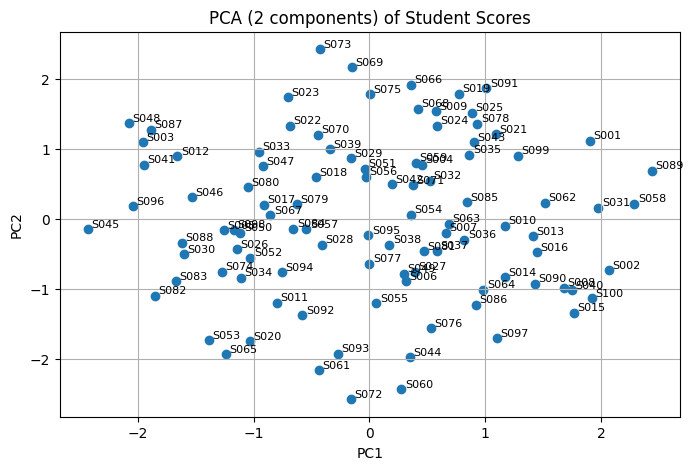

In [11]:
scaler = StandardScaler()
M_scaled = scaler.fit_transform(M)

pca = PCA(n_components=2)
M_pca = pca.fit_transform(M_scaled)

print('Explained variance ratios (2 components):', np.round(pca.explained_variance_ratio_,4))

plt.figure(figsize=(8,5))
plt.title('PCA (2 components) of Student Scores')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.scatter(M_pca[:,0], M_pca[:,1], c='tab:blue')
for i, sid in enumerate(df['Student_ID']):
    plt.text(M_pca[i,0]+0.03, M_pca[i,1]+0.03, sid, fontsize=8)
plt.grid(True)
plt.show()

### Task 11: Linear Discriminant Analysis (LDA)

We create a binary label: "Above Average" if a student's average score >= overall mean, else "Below Average". Then we train LDA to classify students and report accuracy.

In [12]:

df['Average'] = df[subject_cols].mean(axis=1)
overall_mean = df['Average'].mean()
df['Label'] = df['Average'].apply(lambda x: 'Above' if x >= overall_mean else 'Below')

print('Overall mean score:', round(overall_mean,3))
display(df[['Student_ID','Average','Label']].head())

X = M_scaled
y = df['Label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
pred = lda.predict(X_test)

print('\nLDA Classification Results:')
print('Accuracy:', accuracy_score(y_test, pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, pred))
print('\nClassification Report:\n', classification_report(y_test, pred))

Overall mean score: 74.096


,Student_ID,Average,Label
0,S001,72.4,Below
1,S002,68.0,Below
2,S003,83.2,Above
3,S004,59.6,Below
4,S005,74.0,Below



LDA Classification Results:
Accuracy: 0.92

Confusion Matrix:
 [[ 9  2]
 [ 0 14]]

Classification Report:
               precision    recall  f1-score   support

       Above       1.00      0.82      0.90        11
       Below       0.88      1.00      0.93        14

    accuracy                           0.92        25
   macro avg       0.94      0.91      0.92        25
weighted avg       0.93      0.92      0.92        25



## Output Explanation

- Vector representations: each student's scores are rows in matrix `M`.
- Norms provide magnitude of student score vectors; dot products and angles show similarity between students.
- The scatter/multiplication `S = M^T M` is a subjects-by-subjects scatter matrix; its eigen-decomposition reveals principal directions of variance.
- SVD singular values show the energies along orthogonal modes of the data.
- PCA reduces to 2 dimensions while preserving maximal variance (we printed explained variance ratios).
- LDA attempts to find a linear boundary separating "Above" vs "Below" average students; accuracy and report summarize its performance.

## Conclusion

- This practical demonstrated how to represent student scores as vectors and matrices and applied linear algebra tools (norms, projections, eigen/singular decompositions) to analyze the dataset.
- PCA effectively reduced dimensionality for visualization; LDA provided a simple supervised classification into performance categories.
- All code is beginner-friendly and commented; run cells sequentially from the top.